<a target="_blank" href="https://colab.research.google.com/github/seap-udea/pryngles/blob/kiss/tutorials/Quickstart-System.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Pryngles Quickstart with System Interface

This notebook reproduces the spirit of `Quickstart-RingedPlanet.ipynb` but using the modern `System` interface.

The goal is to compute, step by step:

1. Reflected/scattered flux from Planet and Ring.
2. Total flux anomaly in ppm.
3. Degree of polarization.

We also show explicitly how these fluxes are extracted from pandas `DataFrame` objects.

## Execution environment

This code only runs if you are in Google Colab.

In [1]:
import sys
if 'google.colab' in sys.modules:
    !sudo pip install -Uq pryngles

## 1. Imports

In [2]:
import pryngles as pr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spiceypy as spy

%matplotlib inline

## 2. Build a ringed system (System interface)

We mimic the original quickstart geometry: one star, one planet, one ring.

In [3]:
system = pr.System()

star = system.add(
    kind='Star',
    radius=pr.Consts.rsun / system.ul,
    limb_coeffs=[0.65],
)

planet = system.add(
    kind='Planet',
    parent=star,
    a=0.2,
    e=0.0,
    radius=pr.Consts.rsaturn / system.ul,
)

ring = system.add(
    kind='Ring',
    parent=planet,
    fi=1.5,
    fe=2.5,
    i=30 * pr.Consts.deg,
)

print('Bodies:', [b.name for b in [star, planet, ring]])

Bodies: ['Star', 'Planet', 'Ring']


## 3. Observer setup, dynamics, and surface discretization

`System` needs an observer direction, then simulation initialization and spangling.

In [4]:
# Similar viewing geometry to the legacy quickstart
inc = 90.0
omega = 0.0
system.n_obs = spy.eul2m(np.deg2rad(omega), np.deg2rad(inc), 0, 3, 1, 3)[0]

system.initialize_simulation()
system.spangle_system()

print('Initialized:', system._simulated)
print('Spangled:', system._spangled)
print('n_obs:', system.n_obs)

Initialized: True
Spangled: True
n_obs: [1. 0. 0.]


## 4. Time grid over one orbit

In the legacy notebook, stellar position is swept from 0 to 360 deg. Here we sample one full period in time and evaluate the light curve on that grid.

In [5]:
n_times = 181
period_days = 365.25 * (planet.a ** 1.5)  # Approximate Kepler scaling in days
times_days = np.linspace(0.0, period_days, n_times)
times_system = times_days * pr.Consts.day / system.ut

print(f'Period [days] ~ {period_days:.3f}')
print(f'Time grid: {n_times} points')

Period [days] ~ 32.669
Time grid: 181 points


## 5. Compute reflected/scattered flux and polarization

`effects=['polarization']` computes both:

- `scattering`: reflected/scattered flux contribution
- `polarization`: degree of polarization

both as pandas DataFrames indexed by time and split by body.

In [6]:
system.compute_lightcurve(
    times=times_system,
    effects=['polarization'],
)

scattering_df = system.lightcurve['scattering']
polarization_df = system.lightcurve['polarization']

print('Available keys:', list(system.lightcurve.keys()))
print('Scattering columns:', list(scattering_df.columns))
print('Polarization columns:', list(polarization_df.columns))

Computing Lightcurve : 100%|██████████| 181/181 [00:36<00:00,  4.90it/s]

Available keys: ['times', 'total_flux', 'effects', 'bodies', 'observer', 'bandwidth', 'polarization', 'scattering']
Scattering columns: [('Planet', 'scattering'), ('Ring', 'scattering')]
Polarization columns: [('Planet', 'polarization'), ('Ring', 'polarization')]


## 6. Extract Planet, Ring, and Total flux from pandas

This is the key part requested: we take body-wise columns from the DataFrame and build total series explicitly.

In [7]:
# Inspect first rows (optional, educational)
display(scattering_df.head())

# Body contributions
planet_flux = scattering_df['Planet']
ring_flux = scattering_df['Ring']
total_flux = scattering_df.sum(axis=1)

# Convert to ppm anomaly (same style as legacy quickstart)
planet_flux_ppm = pr.Consts.ppm * planet_flux
ring_flux_ppm = pr.Consts.ppm * ring_flux
total_flux_ppm = pr.Consts.ppm * total_flux

print(type(scattering_df))
print('Index type:', type(scattering_df.index))
print('Planet flux shape:', planet_flux.shape)
print('Ring flux shape:', ring_flux.shape)
print('Total flux shape:', total_flux.shape)

body,Planet,Ring
effect,scattering,scattering
time,,
0.000000,0.000000e+00,0.000004
0.003122,2.587745e-11,0.000004
0.006244,1.252107e-10,0.000004
0.009366,2.946362e-10,0.000003
0.012488,5.498182e-10,0.000003


<class 'pandas.DataFrame'>
Index type: <class 'pandas.Index'>
Planet flux shape: (181, 1)
Ring flux shape: (181, 1)
Total flux shape: (181,)


## 7. Plot reflected/scattered flux (Planet, Ring, Planet+Ring)

Equivalent to the first reflected-light plot in the legacy quickstart.

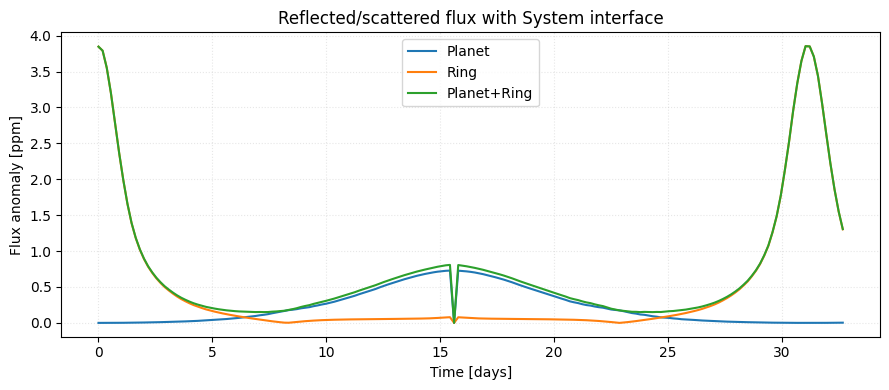

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(times_days, planet_flux_ppm, label='Planet')
ax.plot(times_days, ring_flux_ppm, label='Ring')
ax.plot(times_days, total_flux_ppm, label='Planet+Ring')
ax.set_xlabel('Time [days]')
ax.set_ylabel('Flux anomaly [ppm]')
ax.set_title('Reflected/scattered flux with System interface')
ax.grid(True, alpha=0.3, linestyle=':')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Extract and plot polarization

As in the second part of the legacy quickstart, we plot Planet/Ring/Total polarization degree.

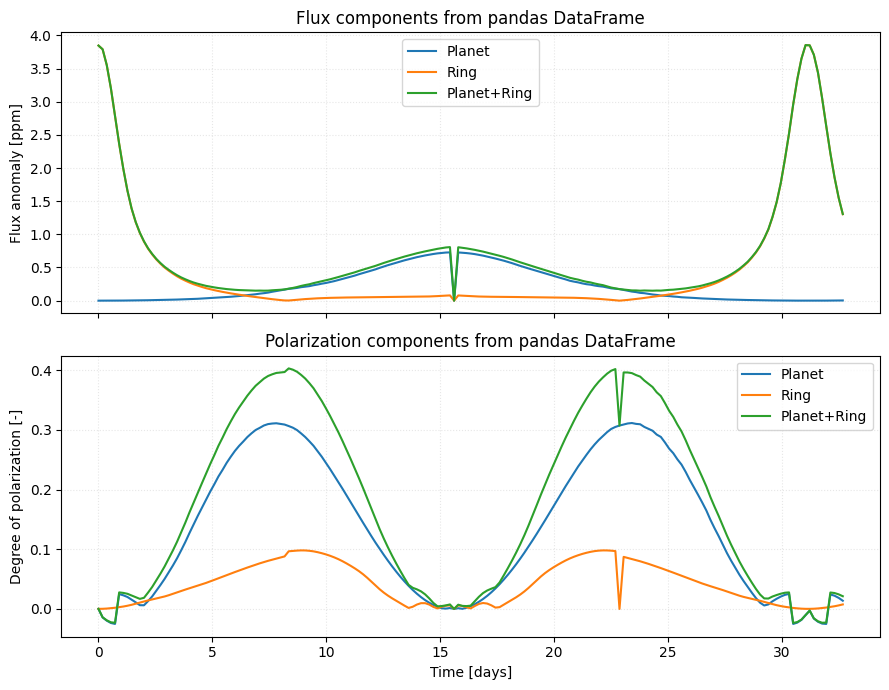

In [9]:
planet_pol = polarization_df['Planet']
ring_pol = polarization_df['Ring']
total_pol = polarization_df.sum(axis=1)

fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axs[0].plot(times_days, planet_flux_ppm, label='Planet')
axs[0].plot(times_days, ring_flux_ppm, label='Ring')
axs[0].plot(times_days, total_flux_ppm, label='Planet+Ring')
axs[0].set_ylabel('Flux anomaly [ppm]')
axs[0].set_title('Flux components from pandas DataFrame')
axs[0].grid(True, alpha=0.3, linestyle=':')
axs[0].legend()

axs[1].plot(times_days, planet_pol, label='Planet')
axs[1].plot(times_days, ring_pol, label='Ring')
axs[1].plot(times_days, total_pol, label='Planet+Ring')
axs[1].set_xlabel('Time [days]')
axs[1].set_ylabel('Degree of polarization [-]')
axs[1].set_title('Polarization components from pandas DataFrame')
axs[1].grid(True, alpha=0.3, linestyle=':')
axs[1].legend()

plt.tight_layout()
plt.show()

## Notes

- This notebook uses `System.compute_lightcurve(...)` instead of the legacy `RingedPlanet` update loop.
- The key outputs are pandas objects in `system.lightcurve`, which can be sliced by effect and body.
- For direct comparison against legacy results, keep geometry, observer, and sampling consistent.